In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
dpdbo = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05.pkl")
dpdbswing = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05Swing.pkl")
dpdbnet = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05net.pkl")
dpdbio = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05io.pkl")
dpdbawt = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05awt.pkl")
dpdbargouml = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05argo.pkl")
dpdbant = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05ant.pkl")
dpdb=pd.concat([dpdbo,dpdbswing,dpdbnet,dpdbio,dpdbawt,dpdbargouml,dpdbant])

In [3]:
import matplotlib.pyplot as plt
import itertools
import numpy as np
from sklearn import svm, datasets
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold


In [4]:
def flatten_list(_2d_list):
    flat_list = []
    for element in _2d_list:
        if type(element) is list:
            for item in element:
                flat_list.append(item)
        else:
            flat_list.append(element)
    return flat_list

In [5]:
dpdb.sample(frac=1)

,Metrics,Patterns
133,"[[75, 6, 69, 34, 1, 0, 34, 0.82222223, 18, 1, ...",Singleton
8,"[[3, 1, 2, 6, 2, 0, 6, 0.22222222, 3, 0, 1, 1,...",Strategy
38,"[[0, 0, 0, 6, 1, 0, 1, 0.5833333, 4, 0, 4, 0, ...",Strategy
8,"[[2, 1, 1, 2, 1, 0, 1, 0.0, 2, 0, 2, 0, 0, 0, ...",Strategy
13,"[[2, 0, 2, 41, 1, 0, 28, 0.91666675, 12, 0, 10...",State
...,...,...
82,"[[5, 3, 2, 10, 1, 0, 17, 0.5, 2, 1, 2, 0, 0, 0...",Flyweight
24,"[[19, 4, 15, 59, 8, 0, 47, 0.81313133, 18, 0, ...",Adapter
66,"[[3, 1, 2, 5, 3, 0, 8, 1.0, 5, 0, 0, 0, 5, 0, ...",Flyweight
70,"[[5, 2, 3, 9, 3, 0, 14, 0.6666667, 3, 1, 2, 0,...",Flyweight


In [6]:
import tensorflow as tf
dpdb=dpdb.sample(frac=1).reset_index()

In [7]:
dpdb=dpdb.drop('index',axis=1)
dpdb=dpdb[dpdb.Metrics.map(len)>=1]
dpdb

,Metrics,Patterns
0,"[[1, 0, 1, 48, 1, 0, 21, 0.9150327, 36, 0, 32,...",Strategy
1,"[[6, 6, 0, 10, 1, 0, 0, 1.0, 10, 0, 0, 0, 0, 1...",Flyweight
2,"[[0, 0, 0, 113, 2, 0, 45, 0.7058823, 34, 0, 14...",Chain_of_Responsibilities
3,"[[0, 0, 0, 28, 2, 0, 5, 0.53571427, 7, 0, 1, 0...",Strategy
4,"[[0, 0, 0, 19, 16, 6, 9, 1.0, 16, 6, 10, 1, 1,...",Template_Method
...,...,...
549,"[[4, 0, 4, 53, 1, 0, 36, 0.95156705, 27, 3, 17...",Strategy
550,"[[1, 0, 1, 7, 2, 0, 3, 0.8333333, 7, 0, 7, 0, ...",Flyweight
551,"[[33, 18, 15, 86, 1, 1, 54, 0.9660326, 69, 1, ...",Flyweight
552,"[[15, 3, 12, 19, 2, 0, 28, 0.78787875, 11, 1, ...",Strategy


In [8]:
#for i,sample in dpdb.items()
import math
for i, sample in dpdb["Metrics"].items():
  for item in sample:
    for j in range(len(item)):
      if  math.isnan(item[j]):
        item[j]=0


In [9]:
dpdb=dpdb.loc[dpdb["Patterns"]!="Mediator"]
dpdb["Patterns"].value_counts()

Flyweight                    196
Strategy                     167
Decorator                     41
State                         35
Adapter                       30
Singleton                     27
Template_Method               25
Chain_of_Responsibilities     24
Proxy                          4
Visitor                        3
Observer                       2
Name: Patterns, dtype: int64

In [10]:
def permute2(lista):
  p=lista[1]
  lista[1]=lista[2]
  lista[2]=p
  return lista

In [11]:
import numpy as np

def permute_vector(vector):
    return np.random.permutation(vector)

def permute_dataset(data):
    permuted_data = {
        "Metrics": [],
        "Patterns": []
    }
    for metrics, label in zip(data["Metrics"], data["Patterns"]):
      permuted_data["Metrics"].append(permute2(metrics))
      permuted_data["Patterns"].append(label)
      for i in range(2):
        arr = np.array(metrics)
        shifted_arr = np.roll(arr, -i+1, axis=0)
        shifted_list = shifted_arr.tolist()
        permuted_data["Metrics"].append(shifted_list)
        permuted_data["Patterns"].append(label)
        permuted_data["Metrics"].append(permute2(shifted_list))
        permuted_data["Patterns"].append(label)
    return permuted_data


permuted_data = pd.DataFrame(permute_dataset(dpdb))

print(permuted_data)
print(dpdb)
dpdb= pd.concat([dpdb,permuted_data], ignore_index=True,axis=0)

                                                Metrics  Patterns
0     [[1, 0, 1, 48, 1, 0, 21, 0.9150327, 36, 0, 32,...  Strategy
1     [[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0,...  Strategy
2     [[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0,...  Strategy
3     [[1.0, 0.0, 1.0, 48.0, 1.0, 0.0, 21.0, 0.91503...  Strategy
4     [[1.0, 0.0, 1.0, 48.0, 1.0, 0.0, 21.0, 0.91503...  Strategy
...                                                 ...       ...
2765  [[6, 0, 6, 68, 11, 0, 52, 0.93509114, 29, 0, 1...     State
2766  [[0.0, 0.0, 0.0, 3.0, 1.0, 0.0, 0.0, 0.0, 3.0,...     State
2767  [[0.0, 0.0, 0.0, 3.0, 1.0, 0.0, 0.0, 0.0, 3.0,...     State
2768  [[6.0, 0.0, 6.0, 68.0, 11.0, 0.0, 52.0, 0.9350...     State
2769  [[6.0, 0.0, 6.0, 68.0, 11.0, 0.0, 52.0, 0.9350...     State

[2770 rows x 2 columns]
                                               Metrics  \
0    [[1, 0, 1, 48, 1, 0, 21, 0.9150327, 36, 0, 32,...   
1    [[6, 6, 0, 10, 1, 0, 0, 1.0, 10, 0, 0, 0, 0, 1...   
2    [[0,

In [12]:
dpdb["Metrics"]

0       [[1, 0, 1, 48, 1, 0, 21, 0.9150327, 36, 0, 32,...
1       [[6, 6, 0, 10, 1, 0, 0, 1.0, 10, 0, 0, 0, 0, 1...
2       [[0, 0, 0, 113, 2, 0, 45, 0.7058823, 34, 0, 14...
3       [[0, 0, 0, 28, 2, 0, 5, 0.53571427, 7, 0, 1, 0...
4       [[0, 0, 0, 19, 16, 6, 9, 1.0, 16, 6, 10, 1, 1,...
                              ...                        
3319    [[6, 0, 6, 68, 11, 0, 52, 0.93509114, 29, 0, 1...
3320    [[0.0, 0.0, 0.0, 3.0, 1.0, 0.0, 0.0, 0.0, 3.0,...
3321    [[0.0, 0.0, 0.0, 3.0, 1.0, 0.0, 0.0, 0.0, 3.0,...
3322    [[6.0, 0.0, 6.0, 68.0, 11.0, 0.0, 52.0, 0.9350...
3323    [[6.0, 0.0, 6.0, 68.0, 11.0, 0.0, 52.0, 0.9350...
Name: Metrics, Length: 3324, dtype: object

In [13]:
Unique_labels=dpdb["Patterns"].unique()

In [14]:
class_names=Unique_labels

In [15]:
labels=dpdb["Patterns"]

In [16]:
labels

0                        Strategy
1                       Flyweight
2       Chain_of_Responsibilities
3                        Strategy
4                 Template_Method
                  ...            
3319                        State
3320                        State
3321                        State
3322                        State
3323                        State
Name: Patterns, Length: 3324, dtype: object

In [17]:
bool_label=[label==Unique_labels for label in labels]

In [18]:
one_hot_label=np.array([bool.astype(int)for bool in bool_label])

In [19]:
one_hot_label[:3]


array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]])

In [20]:
dpdbwith0=dpdb["Metrics"]
max_sample_length = max([len(sample) for sample in dpdbwith0])
zeros_list = [0] * 29

for i, sample in dpdbwith0.items():

    if len(sample) != max_sample_length:
      for j in  range(max_sample_length-len(sample)):
        dpdbwith0[i].append(zeros_list)

In [21]:
max_sample_length

3

In [22]:
dpdbwith0=dpdbwith0.apply(lambda row :flatten_list(row))
dpdbwith0

0       [1, 0, 1, 48, 1, 0, 21, 0.9150327, 36, 0, 32, ...
1       [6, 6, 0, 10, 1, 0, 0, 1.0, 10, 0, 0, 0, 0, 10...
2       [0, 0, 0, 113, 2, 0, 45, 0.7058823, 34, 0, 14,...
3       [0, 0, 0, 28, 2, 0, 5, 0.53571427, 7, 0, 1, 0,...
4       [0, 0, 0, 19, 16, 6, 9, 1.0, 16, 6, 10, 1, 1, ...
                              ...                        
3319    [6, 0, 6, 68, 11, 0, 52, 0.93509114, 29, 0, 18...
3320    [0.0, 0.0, 0.0, 3.0, 1.0, 0.0, 0.0, 0.0, 3.0, ...
3321    [0.0, 0.0, 0.0, 3.0, 1.0, 0.0, 0.0, 0.0, 3.0, ...
3322    [6.0, 0.0, 6.0, 68.0, 11.0, 0.0, 52.0, 0.93509...
3323    [6.0, 0.0, 6.0, 68.0, 11.0, 0.0, 52.0, 0.93509...
Name: Metrics, Length: 3324, dtype: object

In [23]:
reformatted_df = dpdbwith0.apply(pd.Series)

In [24]:
reformatted_df.shape

(3324, 87)

In [25]:
reformatted_df= np.asarray(reformatted_df).astype('float32')

In [26]:
LabelsN=[]
for i,sample in enumerate(one_hot_label):
  for j,k in enumerate(sample):
    if sample[j]==1:
      LabelsN.append(j+1)
      break;
LabelsN=np.array(LabelsN)

In [27]:
scores=[]
precision_scores = []
recall_scores = []
f1_scores = []

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(data_x, data_y):
    k_fold = KFold(5, shuffle=True, random_state=1)

    predicted_targets = np.array([])
    actual_targets = np.array([])

    for train_ix, test_ix in k_fold.split(data_x):
        train_x, train_y, test_x, test_y = data_x[train_ix], data_y[train_ix], data_x[test_ix], data_y[test_ix]


        classifier = svm.SVC(kernel="rbf", gamma=0.7).fit(train_x, train_y)
        scores.append(classifier.score(test_x,test_y))

        predicted_labels = classifier.predict(test_x)
        precision_scores.append(precision_score(test_y, predicted_labels, average=None))
        recall_scores.append(recall_score(test_y, predicted_labels, average=None))
        f1_scores.append(f1_score(test_y, predicted_labels, average=None))

        predicted_targets = np.append(predicted_targets, predicted_labels)
        actual_targets = np.append(actual_targets, test_y)

    return predicted_targets, actual_targets

In [29]:
def plot_confusion_matrix(predicted_labels_list, y_test_list):
    cnf_matrix = confusion_matrix(y_test_list, predicted_labels_list)
    np.set_printoptions(precision=2)

    # Plot non-normalized confusion matrix
    plt.figure()
    generate_confusion_matrix(cnf_matrix, classes=class_names, title='Confusion matrix, without normalization')
    plt.show()

    # Plot normalized confusion matrix
    plt.figure()
    generate_confusion_matrix(cnf_matrix, classes=class_names, normalize=True, title='Normalized confusion matrix')
    plt.show()


In [30]:
dpdb["Patterns"].value_counts()

Flyweight                    1176
Strategy                     1002
Decorator                     246
State                         210
Adapter                       180
Singleton                     162
Template_Method               150
Chain_of_Responsibilities     144
Proxy                          24
Visitor                        18
Observer                       12
Name: Patterns, dtype: int64

In [31]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

def generate_confusion_matrix(cnf_matrix, classes, normalize=False, title='Confusion matrix'):
    if normalize:
        cnf_matrix = cnf_matrix.astype('float') / cnf_matrix.sum(axis=1)[:, np.newaxis] * 100
        print("Normalized confusion matrix")
        fmt = '.2f'
    else:
        print('Confusion matrix, without normalization')
        fmt = 'd'

    f = plt.figure()
    f.set_figwidth(12)
    f.set_figheight(10)
    plt.imshow(cnf_matrix, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cnf_matrix.max() / 2.

    for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
        value = format(cnf_matrix[i, j], fmt)
        if normalize:
            value += '%'
        plt.text(j, i, value, horizontalalignment="center",
                 color="white" if cnf_matrix[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    return cnf_matrix


Confusion matrix, without normalization


<Figure size 640x480 with 0 Axes>

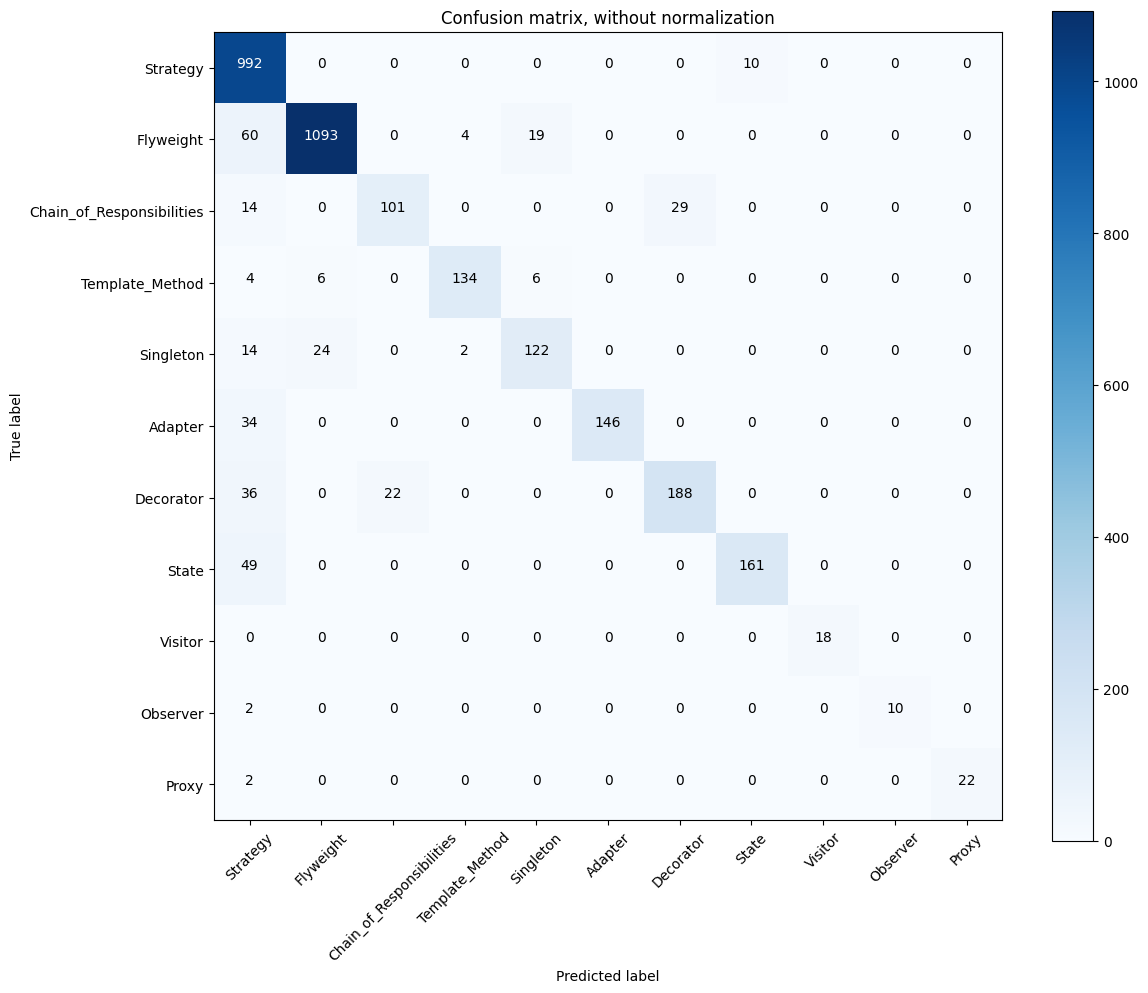

Normalized confusion matrix


<Figure size 640x480 with 0 Axes>

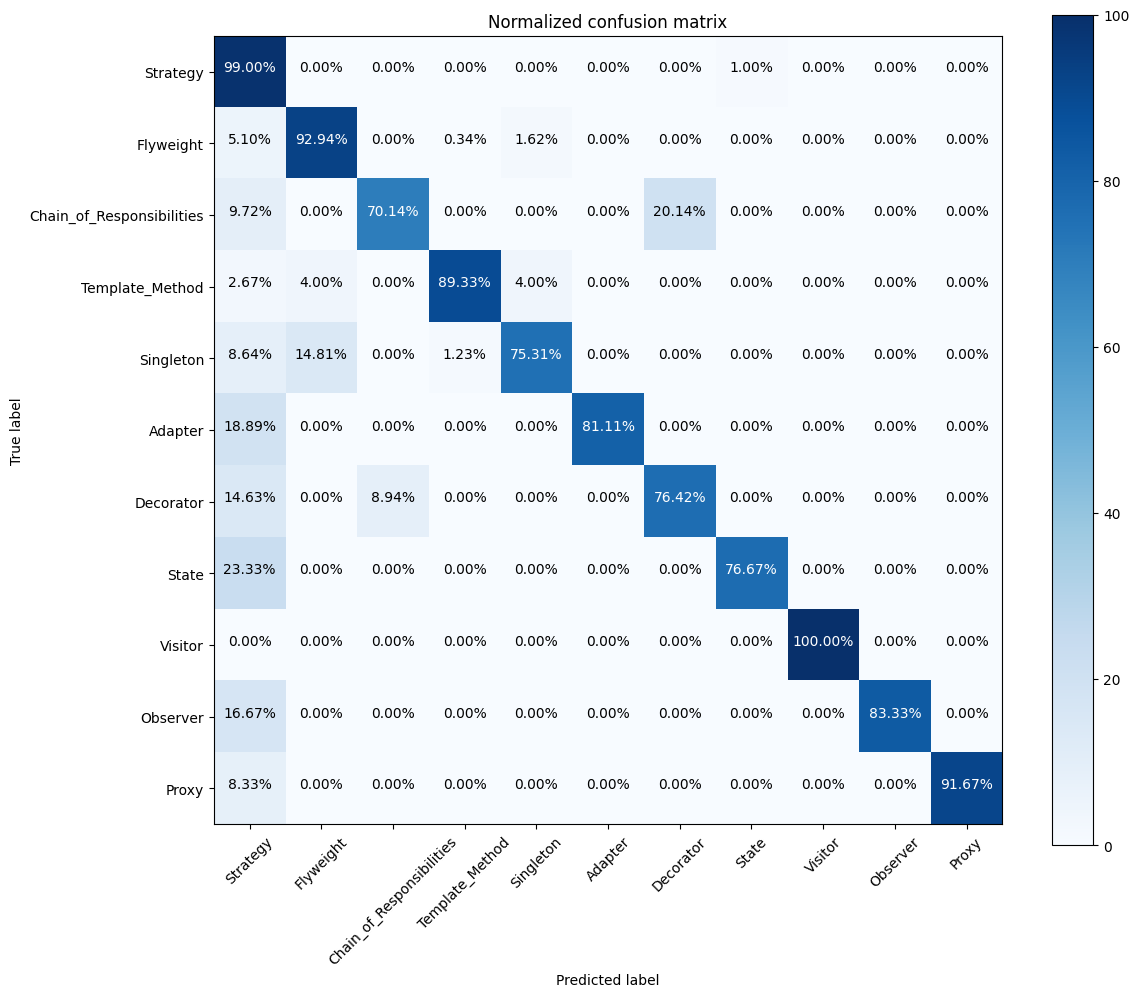

In [32]:
predicted_target, actual_target = evaluate_model(reformatted_df, LabelsN)
plot_confusion_matrix(predicted_target, actual_target)

In [33]:
accuracy = np.mean(scores)
precision = np.mean(precision_scores, axis=0)
recall = np.mean(recall_scores, axis=0)
f1 = np.mean(f1_scores, axis=0)
accuracy,precision,recall,f1

(0.898615363710481,
 array([0.82, 0.97, 0.82, 0.96, 0.84, 1.  , 0.87, 0.94, 1.  , 1.  , 1.  ]),
 array([0.99, 0.93, 0.71, 0.9 , 0.75, 0.81, 0.77, 0.77, 1.  , 0.9 , 0.92]),
 array([0.9 , 0.95, 0.76, 0.93, 0.79, 0.9 , 0.81, 0.84, 1.  , 0.93, 0.95]))